# 1. Treinamento de IA



In [ ]:
import pandas as pd

df = pd.read_csv('spam.csv', encoding='latin-1')

df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


## 1.1. Distribuição das Classes

In [ ]:
print(df['label'].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


# 2. Pré-processamento de Texto Avançado: Lemmatização

In [ ]:
# Instalar a biblioteca NLTK (se ainda não estiver instalada)
!pip install nltk

# Baixar os recursos necessários para NLTK
import nltk
nltk.download('punkt') # Necessário para tokenização
nltk.download('wordnet') # Necessário para lematização
nltk.download('omw-1.4') # Necessário para WordNetLemmatizer
nltk.download('punkt_tab') # Necessário para tokenização de palavras, conforme erro.

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Exemplo de Stemming
stemmer = PorterStemmer()
words = ['running', 'runs', 'runner', 'ran', 'easily', 'fairly']
stemmed_words = [stemmer.stem(word) for word in words]
print(f"Stemmed words: {stemmed_words}")

# Exemplo de Lemmatization
lemmatizer = WordNetLemmatizer()
lemmatized_words = [lemmatizer.lemmatize(w) for w in words] # Corrected 'word' to 'w'
print(f"Lemmatized words: {lemmatized_words}")

# Vamos aplicar Lemmatization ao DataFrame, pois geralmente preserva melhor o significado.
# É importante tokenizar a mensagem antes de lematizar.
def lemmatize_text(text):
    word_list = word_tokenize(text)
    lemmatized_output = ' '.join([lemmatizer.lemmatize(w) for w in word_list])
    return lemmatized_output

df['message_lemmatized'] = df['message'].apply(lemmatize_text)

print("\nDataFrame com mensagens lematizadas (primeiras 5 linhas):")
print(df[['message', 'message_lemmatized']].head())

Stemmed words: ['run', 'run', 'runner', 'ran', 'easili', 'fairli']
Lemmatized words: ['running', 'run', 'runner', 'ran', 'easily', 'fairly']

DataFrame com mensagens lematizadas (primeiras 5 linhas):
                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                  message_lemmatized  
0  Go until jurong point , crazy .. Available onl...  
1                    Ok lar ... Joking wif u oni ...  
2  Free entry in 2 a wkly comp to win FA Cup fina...  
3  U dun say so early hor ... U c already then sa...  
4  Nah I do n't think he go to usf , he life arou...  


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['message_lemmatized'])
y = df['label']

## 4.1. Cross-Validation

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Modelo
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

# Cross Validation
# Avaliando accuracy e f1_weighted
accuracy_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)
f1_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='f1_weighted'
)

print(f"Scores de Acurácia: {accuracy_scores}")
print(f"Média de Acurácia: {round(accuracy_scores.mean()*100)}%")
print(f"\nScores de F1-Score (weighted): {f1_scores}")
print(f"Média de F1-Score (weighted): {round(f1_scores.mean()*100)}%")

Scores de Acurácia: [0.97757848 0.98295964 0.98025135 0.98025135 0.97845601]
Média de Acurácia: 98%

Scores de F1-Score (weighted): [0.97767202 0.9828868  0.97989805 0.98013742 0.97839438]
Média de F1-Score (weighted): 98%


## 4.2. Divisão em Conjuntos de Treino e Teste e Avaliação Detalhada


Relatório de Classificação:

              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       966
        spam       0.96      0.90      0.93       149

    accuracy                           0.98      1115
   macro avg       0.97      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



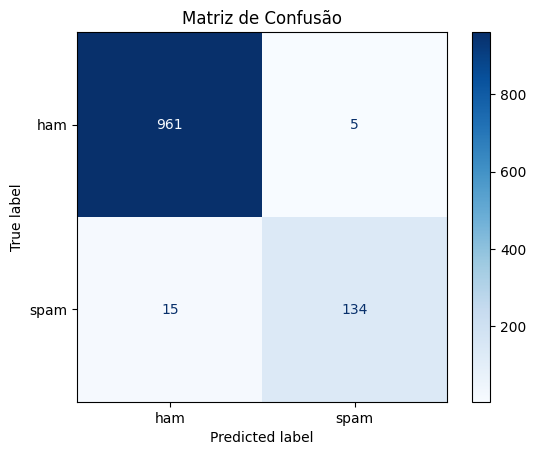

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Dividir os dados em conjuntos de treino e teste
# Usamos stratify=y para manter a mesma proporção de classes 'ham' e 'spam'
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Treinar o modelo no conjunto de treino
model_final = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)
model_final.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred = model_final.predict(X_test)

# Relatório de Classificação Detalhado
print("\nRelatório de Classificação:\n")
print(classification_report(y_test, y_pred))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred, labels=model_final.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_final.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusão')
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Re-obter o vetorizador e o dataframe, se necessário, para garantir que as mensagens originais possam ser acessadas
# Assumindo que 'vectorizer' e 'df' estão disponíveis do estado do notebook.

# Obter os índices dos erros
misclassified_indices = y_test.index[y_test != y_pred]

# Reconstruir o DataFrame de teste com as mensagens originais para análise
# Precisamos do X_test original (não vetorizado) para mapear de volta.
# Para isso, vamos obter os índices reais do df original a partir do train_test_split

# Primeiro, precisamos obter os índices reais das mensagens no dataframe 'df' que foram para o conjunto de teste.
# O `train_test_split` retorna os dados, mas não os índices originais do dataframe se não for especificado.
# Uma forma de fazer isso é recriar o X_test e y_test usando os índices.

# Vamos obter os índices do df original que foram para o conjunto de teste.
# Refaça o split para capturar os índices originais
_, X_test_indices, _, _ = train_test_split(
    df.index, y, test_size=0.2, random_state=42, stratify=y
)

# Filtrar o DataFrame original usando esses índices para obter os dados do teste
df_test_original = df.loc[X_test_indices].copy()

# Adicionar as previsões ao DataFrame de teste original
df_test_original['predicted_label'] = y_pred

# Filtrar apenas as mensagens mal classificadas
misclassified_df = df_test_original[df_test_original['label'] != df_test_original['predicted_label']]

print(f"Total de mensagens mal classificadas: {len(misclassified_df)}")
display(misclassified_df[['message', 'label', 'predicted_label']])

Total de mensagens mal classificadas: 20


,message,label,predicted_label
5,FreeMsg Hey there darling it's been 3 week's n...,spam,ham
914,"Call me da, i am waiting for your call.",ham,spam
573,Waiting for your call.,ham,spam
3979,ringtoneking 84484,spam,ham
3358,Sorry I missed your call let's talk when you h...,spam,ham
5449,"Latest News! Police station toilet stolen, cop...",spam,ham
1268,Can U get 2 phone NOW? I wanna chat 2 set up m...,spam,ham
1939,More people are dogging in your area now. Call...,spam,ham
1429,For sale - arsenal dartboard. Good condition b...,spam,ham
1865,Call to the number which is available in appoi...,ham,spam


### Falsos Positivos (Ham classificado como Spam)

In [ ]:
# Mensagens 'ham' que foram preditas como 'spam'
false_positives = misclassified_df[misclassified_df['label'] == 'ham']

print(f"Total de Falsos Positivos: {len(false_positives)}")
display(false_positives[['message', 'label', 'predicted_label']])

Total de Falsos Positivos: 5


,message,label,predicted_label
914,"Call me da, i am waiting for your call.",ham,spam
573,Waiting for your call.,ham,spam
1865,Call to the number which is available in appoi...,ham,spam
4659,You call him and tell now infront of them. Cal...,ham,spam
5044,We have sent JD for Customer Service cum Accou...,ham,spam


### Falsos Negativos (Spam classificado como Ham)

In [ ]:
# Mensagens 'spam' que foram preditas como 'ham'
false_negatives = misclassified_df[misclassified_df['label'] == 'spam']

print(f"Total de Falsos Negativos: {len(false_negatives)}")
display(false_negatives[['message', 'label', 'predicted_label']])

Total de Falsos Negativos: 15


,message,label,predicted_label
5,FreeMsg Hey there darling it's been 3 week's n...,spam,ham
3979,ringtoneking 84484,spam,ham
3358,Sorry I missed your call let's talk when you h...,spam,ham
5449,"Latest News! Police station toilet stolen, cop...",spam,ham
1268,Can U get 2 phone NOW? I wanna chat 2 set up m...,spam,ham
1939,More people are dogging in your area now. Call...,spam,ham
1429,For sale - arsenal dartboard. Good condition b...,spam,ham
730,Email AlertFrom: Jeri StewartSize: 2KBSubject:...,spam,ham
1153,1000's of girls many local 2 u who r virgins 2...,spam,ham
606,XCLUSIVE@CLUBSAISAI 2MOROW 28/5 SOIREE SPECIAL...,spam,ham


In [ ]:
import joblib

joblib.dump(model_final, 'spam_model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')

['vectorizer.pkl']

In [ ]:
msg = ["Congratulations! You won a FREE iPhone!"]

data = vectorizer.transform(msg)

prediction = model_final.predict(data)

print(prediction)

['spam']


## 6. Teste Interativo do Modelo

In [ ]:
import ipywidgets as widgets
from IPython.display import display

# Criar um widget de texto para entrada do usuário
text_input = widgets.Textarea(
    value='',
    placeholder='Digite a mensagem aqui para testar o modelo...',
    description='Mensagem:',
    disabled=False,
    layout=widgets.Layout(width='auto', height='100px')
)

# Criar um widget de botão para acionar a previsão
predict_button = widgets.Button(
    description='Prever',
    disabled=False,
    button_style='success', # 'success', 'info', 'warning', 'danger' or ''
    tooltip='Clique para prever se a mensagem é spam ou ham'
)

# Criar um widget de saída para exibir o resultado
output_label = widgets.Output()

def on_button_click(b):
    with output_label:
        output_label.clear_output() # Limpa a saída anterior
        message_to_predict = text_input.value

        if not message_to_predict:
            print("Por favor, digite uma mensagem para prever.")
            return

        # 1. Lematizar a mensagem de entrada
        lemmatized_message = lemmatize_text(message_to_predict)

        # 2. Vetorizar a mensagem lematizada
        data_transformed = vectorizer.transform([lemmatized_message])

        # 3. Fazer a previsão
        prediction = model_final.predict(data_transformed)

        print(f"Mensagem digitada: '{message_to_predict}'")
        print(f"Mensagem lematizada: '{lemmatized_message}'")
        print(f"O modelo previu: {prediction[0].upper()}")

# Conectar o botão à função de clique
predict_button.on_click(on_button_click)

# Exibir os widgets
display(text_input, predict_button, output_label)


### Teste com Exemplos Adicionais

Você também pode criar uma lista de mensagens para testar de uma vez e ver os resultados. Isso é útil para casos de uso específicos que você queira destacar.

In [ ]:
test_messages = [
    "Congratulations! You've won a free iPhone! Click here to claim.", # Spam
    "Hey, let's catch up for coffee tomorrow?", # Ham
    "URGENT! Your bank account has been compromised. Verify your details now.", # Spam
    "Call me back, I missed your call.", # Ham (Pode ser um falso positivo como vimos na análise de erros)
    "Hope you are doing well.", # Ham
    "Free entry to exclusive club offer, reply STOP to opt-out.", # Spam
    "Did you get my email about the meeting?"] # Ham

for i, msg in enumerate(test_messages):
    # Lematizar e vetorizar
    lemmatized_msg = lemmatize_text(msg)
    data_transformed = vectorizer.transform([lemmatized_msg])

    # Prever
    prediction = model_final.predict(data_transformed)

    print(f"--- Mensagem {i+1} ---")
    print(f"Mensagem: '{msg}'")
    print(f"Previsão: {prediction[0].upper()}\n")


Essas ferramentas interativas devem te ajudar a validar o modelo e a preparar uma boa demonstração para o LinkedIn!

Se precisar de algo mais, como sugestões para a postagem no LinkedIn ou análise mais aprofundada, me diga!